In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import XGate
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

from qiskit.primitives import StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [2]:
from hamlib_snippets import get_hdf5_keys, read_qiskit_hdf5
keys = get_hdf5_keys('heis.hdf5')
# print(keys)

In [3]:
num_sites = [3, 5, 10]
couplings = [0, 0.1, 0.5, 1, 2, 3, 5]

hamiltonians = dict()
for n, h in product(num_sites, couplings) :
    hamiltonian = read_qiskit_hdf5('heis.hdf5', f'graph-1D-grid-nonpbc-qubitnodes_Lx-{n}_h-{h}')
    hamiltonians[(n, h)] = hamiltonian
    print(n, h, hamiltonian)

3 0 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
3 0.1 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.1+0.j, 0.1+0.j,
 0.1+0.j])
3 0.5 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])
3 1 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
3 2 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 2.+0.j, 2.+0.j, 2.+0.j])
3 3 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.

In [4]:
def spsa(
    fun, x0, args=(), A=30, alpha=0.9, a=0.3, c=0.1, gamma=0.4, maxiter=100
):
    nparams = len(x0)
    x = np.copy(x0)

    for i in range(maxiter):
        a_i = a / (A + i + 1) ** alpha
        c_i = c / (i + 1) ** gamma
        delta_i = np.random.choice([-1, 1], nparams)

        # two hardware calls
        eval_1 = fun(x + c_i * delta_i, *args)
        eval_2 = fun(x - c_i * delta_i, *args)

        # compute the gradient and update the parameters
        grad = (eval_1 - eval_2) / (2 * c_i) * np.reciprocal(delta_i)
        x = x - a_i * grad

    return x

In [5]:
def cost_func(
    params: Sequence,
    ansatz: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    estimator: BaseEstimatorV2,
    cost_history_dict: dict,
) -> float:
    
    """Ground state energy evaluation."""
    energy = (
        estimator.run([(ansatz, hamiltonian, [params])]).result()[0].data.evs
    )

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = list(params)
    cost_history_dict["cost_history"].append(float(energy[0]))

    print(
        f"Fx Iters. done: {cost_history_dict['iters']} [Current cost: {round(energy[0], 5)}]",
        end="\r",
    )

    return energy


def solve(x0, isa_ansatz, isa_observable, maxiter=150):
    cost_history_dict = {
        "prev_vector": None,
        "iters": 0,
        "cost_history": [],
        "y_min": None,
    }

    # Evaluate the problem using a QPU via Qiskit IBM Runtime
    estimator = StatevectorEstimator()
    estimator.skip_transpilation = True
    x_opt = spsa(
        cost_func,
        x0=x0,
        args=(isa_ansatz, isa_observable, estimator, cost_history_dict),
        maxiter=maxiter,
    )

    y_min = cost_func(
        x_opt, isa_ansatz, isa_observable, estimator, cost_history_dict
    )

    return y_min, cost_history_dict

In [6]:
def visualize_results(results):
    plt.plot(results["cost_history"], lw=2)
    plt.xlabel("Number of function evaluations")
    plt.ylabel("Energy")
    plt.show()

In [7]:
def train(n, h) :
    ansatz = efficient_su2(num_qubits=n, reps=2)
    backend = FakeGuadalupeV2()
    ansatz.draw("mpl", style="iqp")
    
    target = backend.target
    pm = generate_preset_pass_manager(optimization_level=3, target=target)
    isa_ansatz = pm.run(ansatz)
    hamiltonian = hamiltonians[(n, h)]
    isa_observable = hamiltonian.apply_layout(isa_ansatz.layout)
    isa_ansatz.draw("mpl", scale=0.6, style="iqp", fold=-1, idle_wires=False)

    np.random.seed(42)
    num_params = ansatz.num_parameters
    params = 2 * np.pi * np.random.random(num_params)

    maxiter = 500
    spsa_min, spsa_history = solve(
        params, isa_ansatz, isa_observable, maxiter=maxiter
    )
    print(f"Estimated ground state energy for n={n}, h={h}: {spsa_min}")

    results = {
        "spsa": spsa_history,
    }

    visualize_results(spsa_history)

    opt_params = spsa_history['prev_vector']
    np.save(f'params/params_{n}_{h}', opt_params)

Estimated ground state energy for n=3, h=0: [-1.91026095]


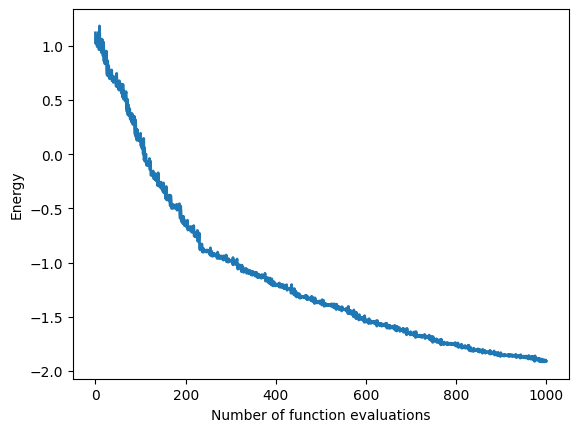

Estimated ground state energy for n=3, h=0.1: [-2.23617471]


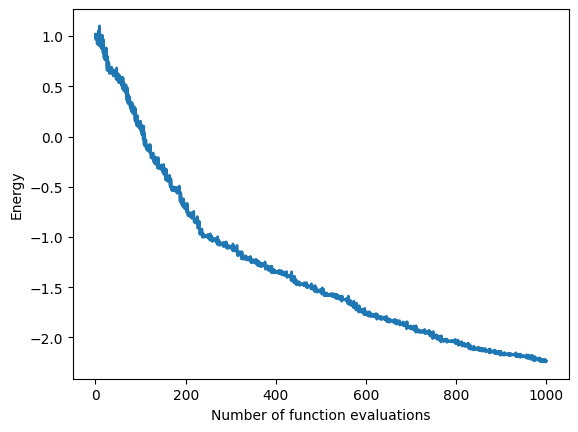

Estimated ground state energy for n=3, h=0.5: [-3.12160055]


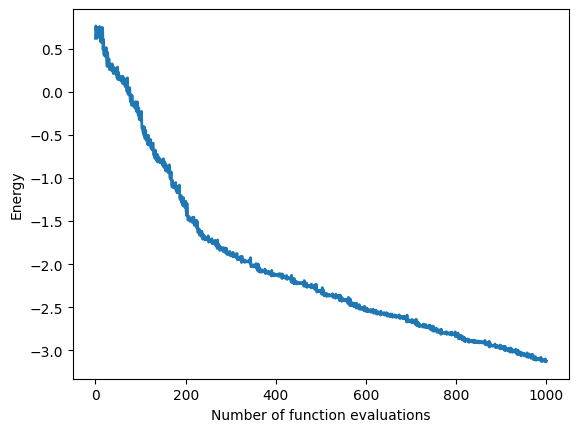

Estimated ground state energy for n=3, h=1: [-3.30906147]


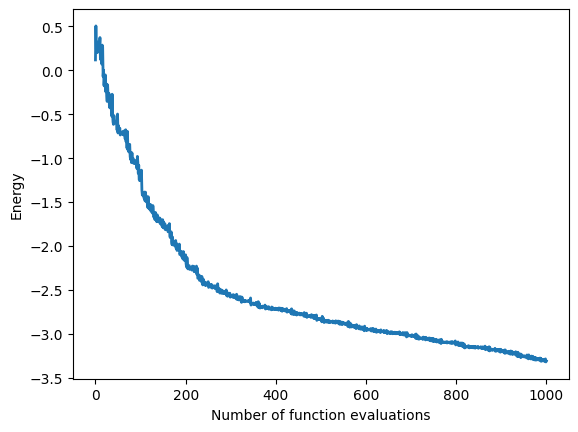

Estimated ground state energy for n=3, h=2: [-4.45412176]


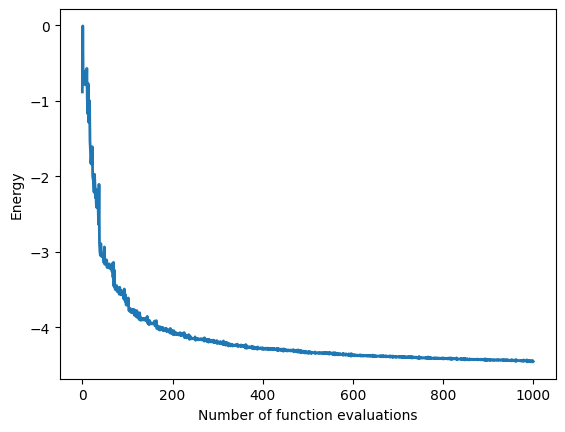

Estimated ground state energy for n=3, h=3: [-6.94369644]


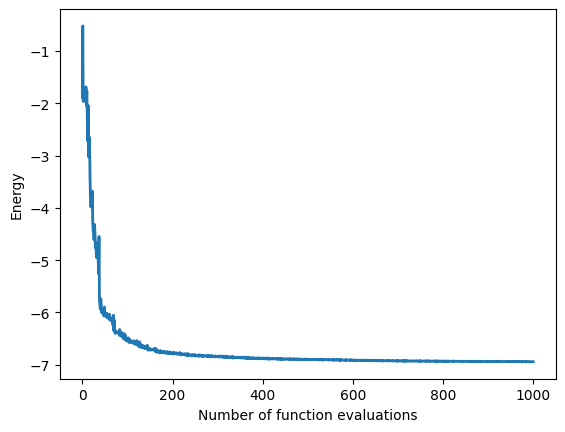

Estimated ground state energy for n=3, h=5: [-12.88964033]


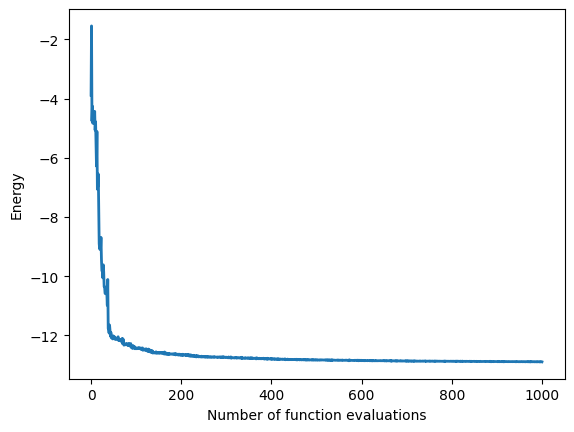

Estimated ground state energy for n=5, h=0: [-5.58868479]


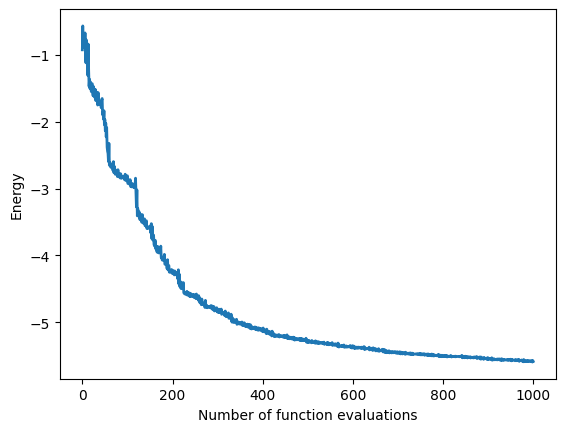

Estimated ground state energy for n=5, h=0.1: [-5.53553798]


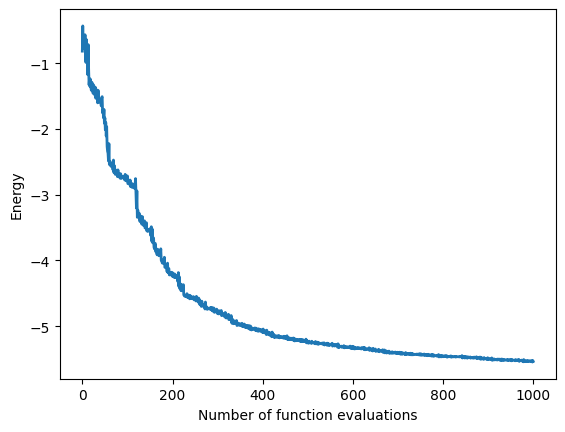

Estimated ground state energy for n=5, h=0.5: [-5.40924788]


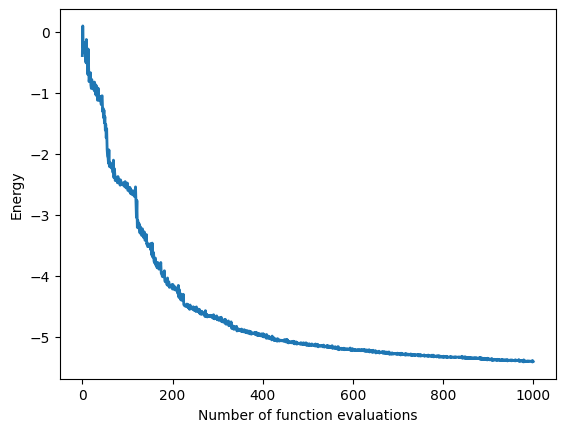

Estimated ground state energy for n=5, h=1: [-5.61366462]


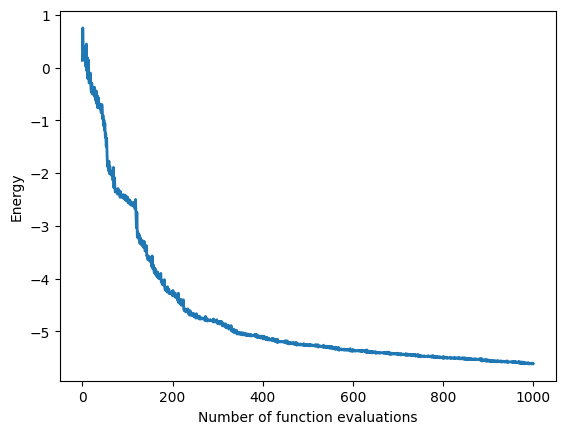

Estimated ground state energy for n=5, h=2: [-6.80881858]


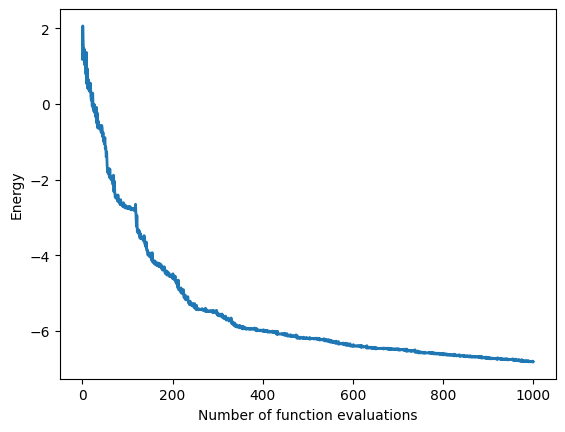

Estimated ground state energy for n=5, h=3: [-10.8066482]


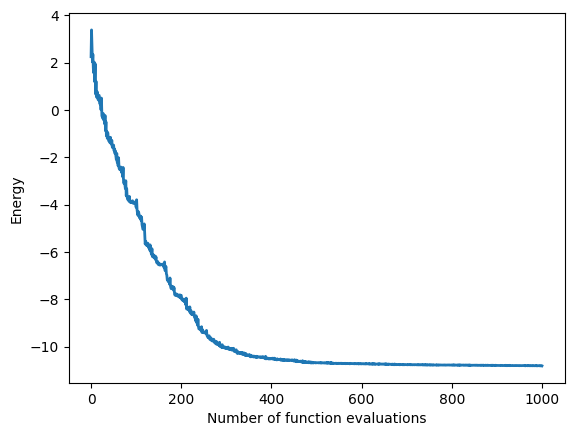

Estimated ground state energy for n=5, h=5: [-20.93662812]


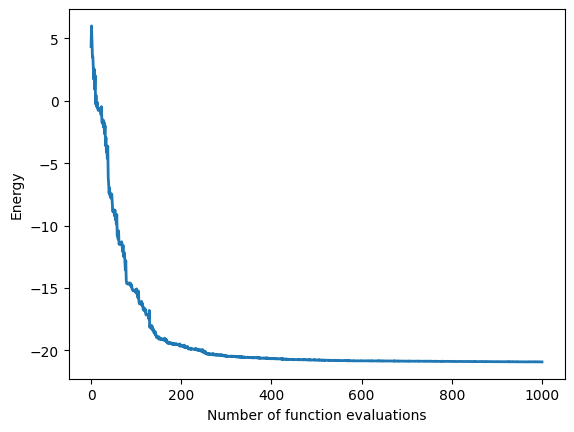

Estimated ground state energy for n=10, h=0: [-10.16287281]


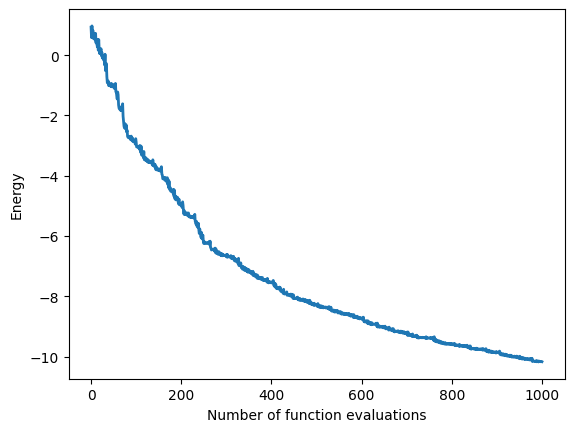

Estimated ground state energy for n=10, h=0.1: [-10.23992509]


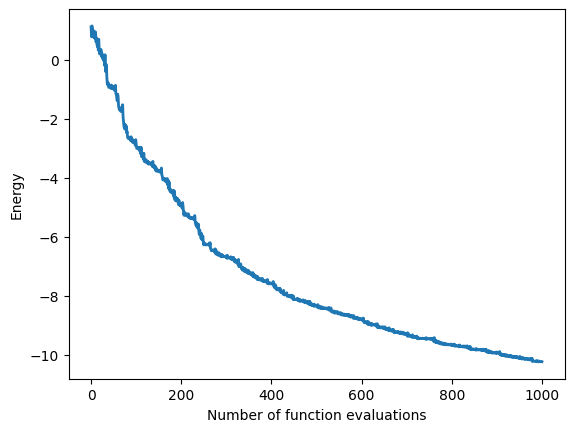

Estimated ground state energy for n=10, h=0.5: [-10.33148342]


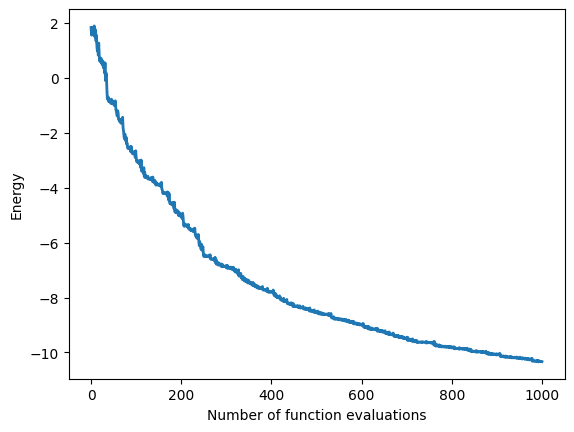

Estimated ground state energy for n=10, h=1: [-9.96677324]


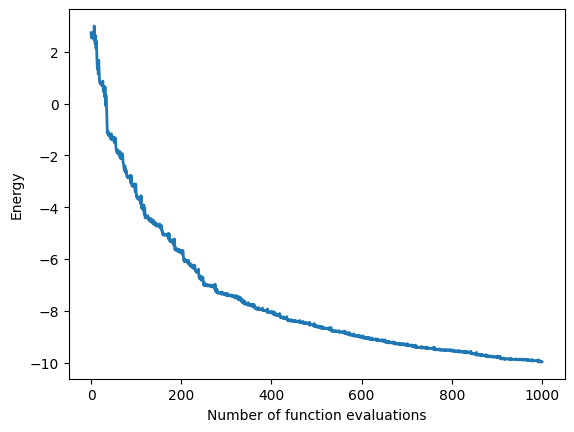

Estimated ground state energy for n=10, h=2: [-14.20766908]


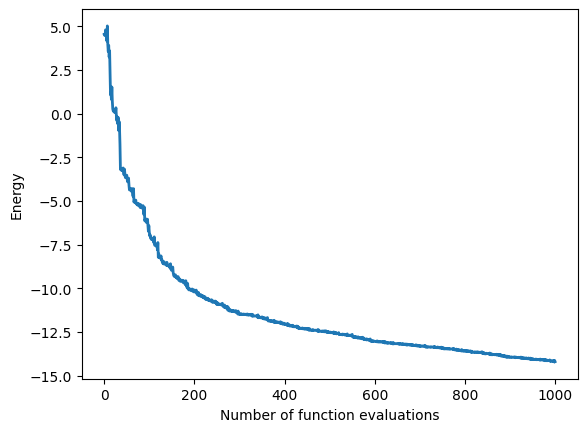

Estimated ground state energy for n=10, h=3: [-20.49422074]


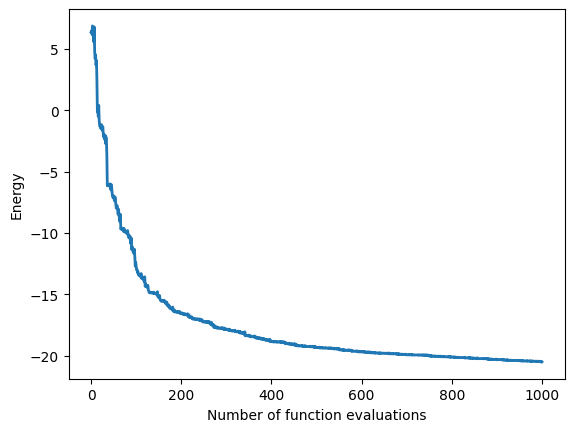

Estimated ground state energy for n=10, h=5: [-35.00527777]


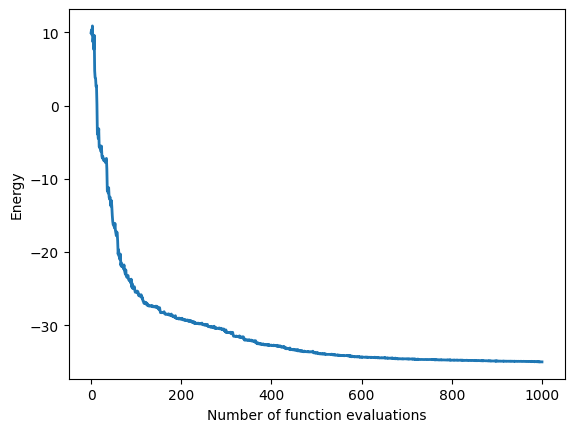

In [8]:
for n, h in product(num_sites, couplings) :
    train(n, h)